In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

In [5]:
complete_df = pd.read_csv("../data/main/COMPLETE_edc_artist_and_stats.csv")
complete_df.head()

,artist,followers,streams,playlists,playlist reach,charts,shazams,videos,views,dj supports,total_appearances,years_played,agency
0,1080p,6,5986,1,641,0,17,45,9800,0,1,2024,insomniac
1,a shade of black,0,15100,0,11000,7,0,0,0,0,1,2024,NaN
2,aaron k,1,2163,0,0,1,4,2,0,0,2,"2024, 2025",insomniac
3,abana,7710,468000,175,4220000,60,15300,110,1890000,93,3,"2022, 2023, 2024",insomniac
4,d. zeledon,5776,69600,25,218000,18,764,31,9672,58,1,2024,insomniac


Pie chart reperesenting how many percent of each agency


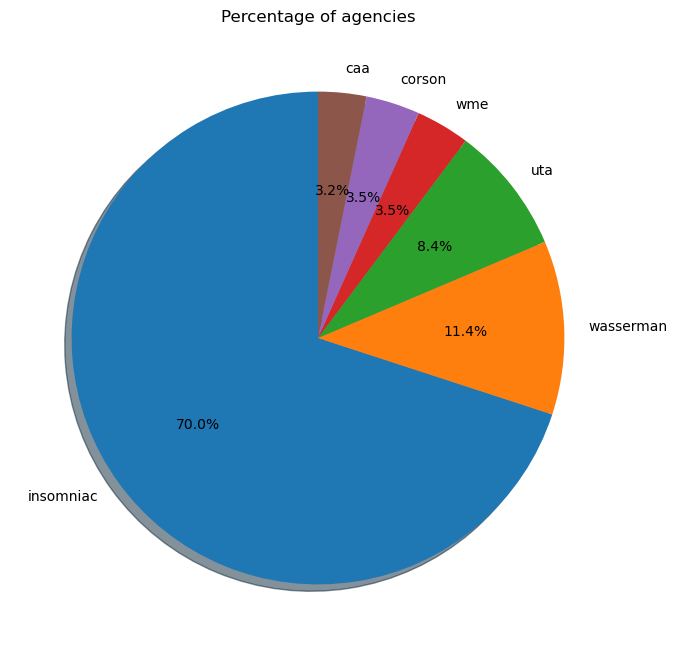

In [7]:
agency = complete_df['agency']      # The values for each slice

# Plot the pie chart
plt.figure(figsize=(8, 8)) # Optional: Adjust the figure size
plt.pie(
    agency.value_counts(),  # The values for each slice
    labels=agency.value_counts().index,
    autopct='%1.1f%%',  # Display percentage values on the slices
    startangle=90,      # Start the first slice at 90 degrees (top)
    shadow=True         # Add a shadow effect
)

plt.title('Percentage of agencies') # Add a title to the chart
plt.axis('equal') # Ensures the pie chart is drawn as a perfect circle
plt.show() # Display the chart

## Distribution of Numeric Metrics (Log Scale)
Histograms showing the distribution of streams, followers, and views

In [ ]:
import seaborn as sns

# Create subplots for distribution of key metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Filter out zeros for log scale
metrics = ['streams', 'followers', 'views']
titles = ['Streams Distribution', 'Followers Distribution', 'Views Distribution']

for ax, metric, title in zip(axes, metrics, titles):
    # Filter positive values for log scale
    data = complete_df[complete_df[metric] > 0][metric]
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7)
    ax.set_xscale('log')
    ax.set_xlabel(metric.capitalize())
    ax.set_ylabel('Frequency')
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Correlation Heatmap
Visualizing relationships between numeric metrics

In [ ]:
# Select numeric columns for correlation
numeric_cols = ['followers', 'streams', 'playlists', 'playlist reach', 
                'charts', 'shazams', 'videos', 'views', 'dj supports', 'total_appearances']

# Calculate correlation matrix
corr_matrix = complete_df[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Artist Metrics')
plt.tight_layout()
plt.show()

## Top Artists Bar Charts
Top 10 artists by streams, followers, and total appearances

In [ ]:
# Remove duplicates to get unique artists (keep first occurrence)
unique_artists = complete_df.drop_duplicates(subset='artist', keep='first')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Top 10 by Streams
top_streams = unique_artists.nlargest(10, 'streams')[['artist', 'streams']]
axes[0].barh(top_streams['artist'], top_streams['streams'], color='steelblue')
axes[0].set_xlabel('Streams')
axes[0].set_title('Top 10 Artists by Streams')
axes[0].invert_yaxis()

# Top 10 by Followers
top_followers = unique_artists.nlargest(10, 'followers')[['artist', 'followers']]
axes[1].barh(top_followers['artist'], top_followers['followers'], color='coral')
axes[1].set_xlabel('Followers')
axes[1].set_title('Top 10 Artists by Followers')
axes[1].invert_yaxis()

# Top 10 by Total Appearances
top_appearances = unique_artists.nlargest(10, 'total_appearances')[['artist', 'total_appearances']]
axes[2].barh(top_appearances['artist'], top_appearances['total_appearances'], color='seagreen')
axes[2].set_xlabel('Total Appearances')
axes[2].set_title('Top 10 Artists by EDC Appearances')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()